In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
from sklearn import linear_model as lm
from sklearn.metrics import mean_squared_error
from sklearn import preprocessing as pre
# Formulate question: I want to find out whether midterm grade and study hour together would have a big influence on the final grade. 
#Also, I would like to see if Mother and father's job would have a linear relationship with students' final.
# during the process, I will visualize some of the data 
# What's more, I am a little curious about the regression model that we use to train our linear model, therefore I would like to explore three:SGD regressor; Random Forest,and linearregression
# to see which training way is better.



#use panda to read for convenience
df = pd.read_csv('students.csv')
#Here I first check whether the data has missing values
print("Total missing values:", df.isnull().sum().sum())


# now let us do the data cleaning
#check all numeric values whether in the boundaries,I don't want to manually check, which is time consuming, therefore by checking the numeric boudary values.
# Here I check, whether studytime, age, Fedu,Medu,traveltime,studytime,failures,freetime,Dalc,Walc,absences,midterm,final are all numeric values and extract them.
# Here, I consider no students could get zero for final,because I have observed no students get 0 for midterm, therefore 0 might occur due to some unexpected reasons, therefore I choose to ignore these 0 data. 
#now we have extracted effective data that is represented by numbers 
df_cleaned = df[df['studytime'].isin([1,2,3,4])&
df['age'].isin([15,16,17,18,19,20,21,22])&
df['Fedu'].isin([0,1,2,3,4])&
df['Medu'].isin([0,1,2,3,4])&
df['traveltime'].isin([1,2,3,4])&
df['studytime'].isin([1,2,3,4])&
df['failures'].isin([0,1,2,3])
&df['freetime'].isin([1,2,3,4,5])
&df['Dalc'].isin([1,2,3,4,5])
&df['Walc'].isin([1,2,3,4,5])&
(df['absences']>=0)& (df['absences']<=93) & df['absences'].apply(lambda x: float (x).is_integer()) 
& (df['midterm']>=0)&(df['midterm']<=100)&df['midterm'].apply(lambda x: float(x).is_integer())& (df['final']!=0)]

print(df_cleaned.shape)
# Here is the shape of the cleaned data.





Total missing values: 0
(357, 21)


In [24]:
# This is only for mark of some attributes that I am going to explore in the following blocks. 
# Note I like to use X2 ,which is also the Y in this scenario to represent the final grade. 
from sklearn import preprocessing as pre
X1 = df_cleaned['midterm'].values
X2 = df_cleaned['final'].values


Text(0.5, 1.0, 'Midterm')

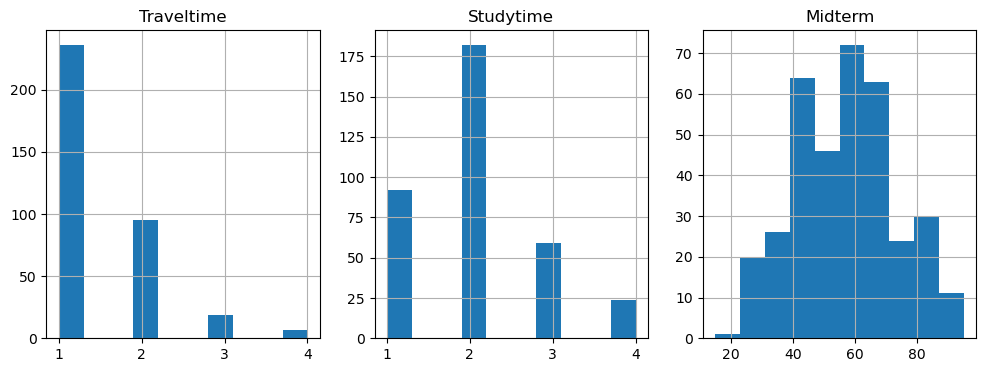

In [25]:
# visualize some of the data with histograms: This is just for visualization of some of the data

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
df_cleaned['traveltime'].hist()
plt.title("Traveltime")
plt.subplot(1,3,2)
df_cleaned['studytime'].hist()
plt.title("Studytime")
plt.subplot(1,3,3)
df_cleaned['midterm'].hist()
plt.title("Midterm")

#it's interesting to see the midterm grade is distributed like a normal distribution

Text(0, 0.5, 'final grade')

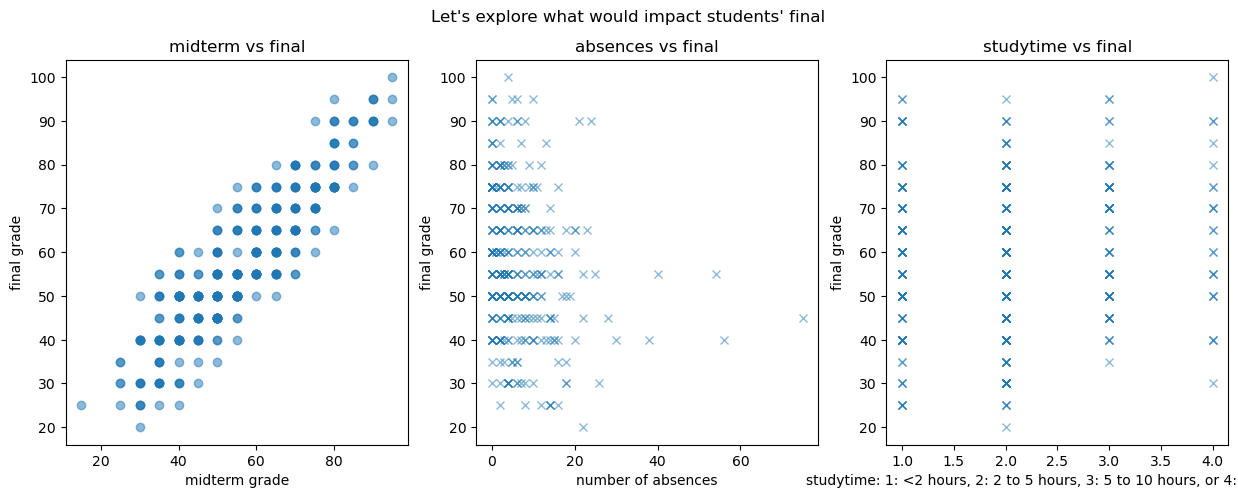

In [26]:
#scatter point visualiztion
# This is to use scatter point to describe how factors such as midterm grade, number of absences, and studytime would influence or not influence final.
# similar to what we did in class
import matplotlib.pyplot as plt
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,5))
fig.suptitle("Let's explore what would impact students' final")
x1 = df_cleaned['midterm']
x2 = df_cleaned['absences']
x3 =df_cleaned['studytime']
y = df_cleaned['final']

ax1.plot(x1, y, 'o',alpha=0.5)
ax1.set_title("midterm vs final")
ax1.set_xlabel("midterm grade")
ax1.set_ylabel("final grade")

ax2.plot(x2,y,'x', alpha = 0.5)
ax2.set_title("absences vs final")
ax2.set_xlabel("number of absences")
ax2.set_ylabel("final grade")

ax3.plot(x3,y,'x', alpha = 0.5)
ax3.set_title("studytime vs final")
ax3.set_xlabel("studytime: 1: <2 hours, 2: 2 to 5 hours, 3: 5 to 10 hours, or 4:>10 hours")
ax3.set_ylabel("final grade")


# You can tell from the scatter point that midterm seems to be a good feature. 

<Axes: xlabel='absences', ylabel='final'>

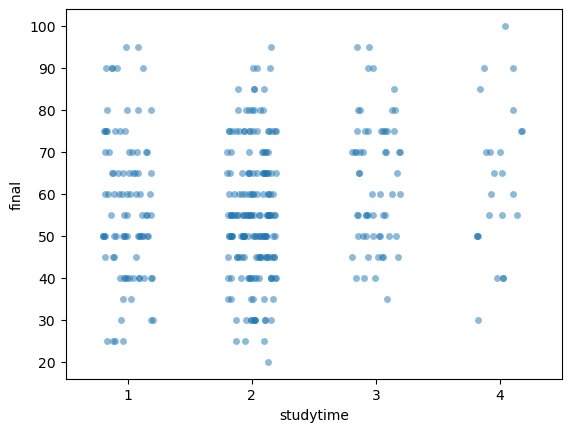

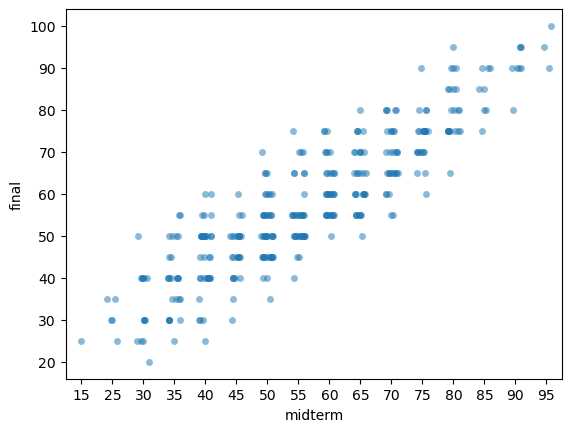

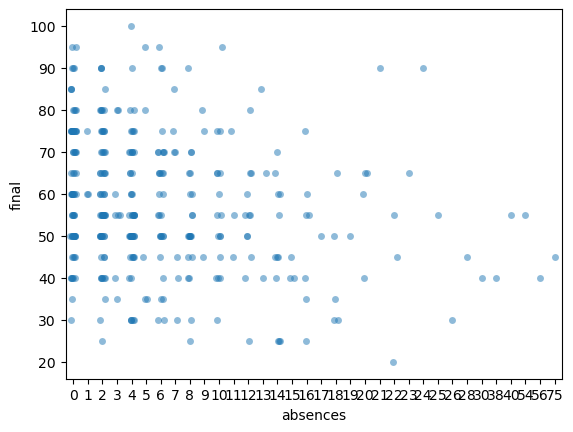

In [27]:
#use another library to better visualize
# I want to see the overlap visual.
#Note the heavy or light extent of the shadow demonstrates the overlap ratio
import seaborn as sns
plt.figure()
sns.stripplot(x = 'studytime',y='final', data = df_cleaned, jitter = 0.2, alpha = 0.5)
plt.figure()
sns.stripplot(x = 'midterm',y='final', data = df_cleaned, jitter = 0.2, alpha = 0.5)
plt.figure()
sns.stripplot(x = 'absences',y='final', data = df_cleaned, jitter = 0.2, alpha = 0.5)

In [28]:
# Here, as I said, I would like to see if mother and father's job would have a influence on students' final.
# Therefore, I re-encode the string using pandas inside function get_dummies. which automatically transforms the different answers as different features.
# Note: I use X2 to denote the final grade values (without scaling) and that's why the MSE is large.
df_encoded = pd.get_dummies(df_cleaned, columns=['Mjob', 'Fjob'], drop_first=True)
X_1 = df_encoded['Mjob_health'].values
X_2 = df_encoded['Mjob_other'].values
X_3 = df_encoded['Mjob_services'].values
X_4 = df_encoded['Mjob_teacher'].values
X_11 = df_encoded['Fjob_health'].values
X_22 = df_encoded['Fjob_other'].values
X_33 = df_encoded['Fjob_services'].values
X_44 = df_encoded['Fjob_teacher'].values
X2 = X2.ravel()
train_Xa = np.concatenate([X_1.reshape(-1,1),
                     X_2.reshape(-1,1),
                     X_3.reshape(-1,1),
                     X_4.reshape(-1,1),
                     X_11.reshape(-1,1),
                     X_22.reshape(-1,1),
                     X_33.reshape(-1,1),
                     X_44.reshape(-1,1)], axis=1)
reg = lm.SGDRegressor(max_iter=1000)
reg.fit(train_Xa, X2) #note X2 is now y
print("R2=" + str(reg.score(train_Xa, X2)))
train_yPred = reg.predict(train_Xa)
print("MSE=" + str(mean_squared_error(X2, train_yPred)))
#R2 is not good, and the MSE is very big(you can see the normal range of MSE within a good model in following blocks) therefore, the mother and father's job almost has little influence on student's final.
reg.coef_

R2=0.06531449980945214
MSE=242.77262108123838


array([11.22955894,  0.87093067,  6.6594445 ,  4.35720699,  1.11304003,
        1.5969721 ,  0.91918653, 11.32923563])

Midterm vs final: R2=0.7953162133015945
Midterm vs final: MSE=53.16399941956383


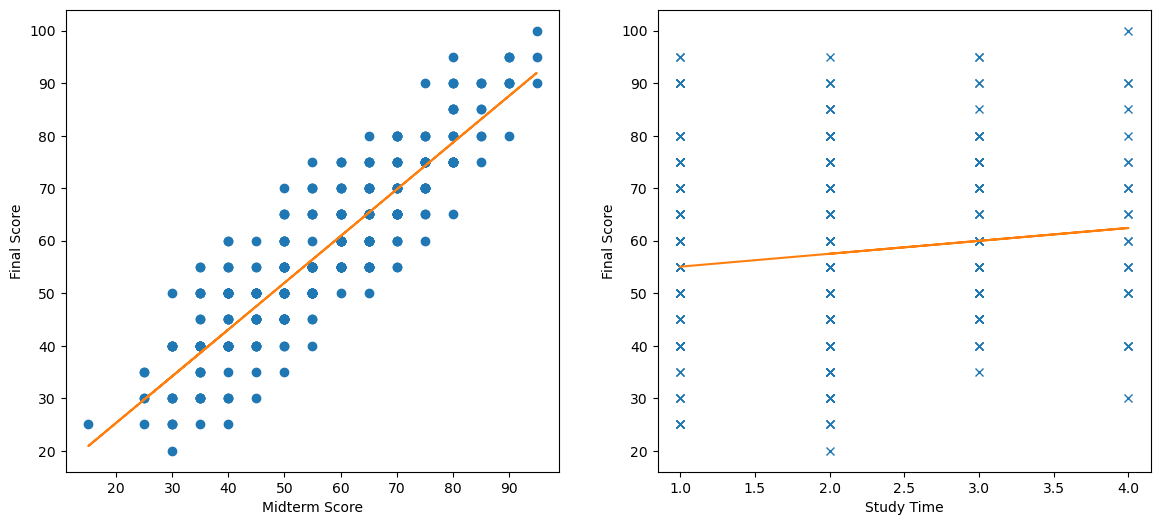

In [29]:
# try linear model with midterm and final , study time and final. Still: Note again: X2 is the final grade values, the Y, but I like to write in this way.
from sklearn import linear_model as lm
from sklearn.metrics import mean_squared_error
from sklearn import preprocessing as pre
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,6))
x3 =df_cleaned['studytime'].values
reg = lm.LinearRegression()
reg.fit(X1.reshape(-1,1),X2)
ypred1 = reg.predict(X1.reshape(-1,1))
ax1.plot(X1, X2, 'o')
ax1.plot(X1, ypred1)
ax1.set_xlabel("Midterm Score")
ax1.set_ylabel("Final Score")

reg1 = lm.LinearRegression()
reg1.fit(x3.reshape(-1,1),X2)
ypred2 = reg1.predict(x3.reshape(-1,1))
ax2.plot(x3, X2, 'x')
ax2.plot(x3, ypred2)
ax2.set_xlabel("Study Time")
ax2.set_ylabel("Final Score")



print("Midterm vs final: R2=" + str(reg.score(X1.reshape(-1,1), X2)))
print("Midterm vs final: MSE=" + str(mean_squared_error(X2, ypred1)))

# Because I did not scale the Y, which is X2 in this case(the final grade), therefore it is expectable to get MSE like this. 
#the model is pretty good you see: The R2 is pretty close to 1, and MSE is smaller. Next, I am going to see, whether polynomial feature can get me better R2. 

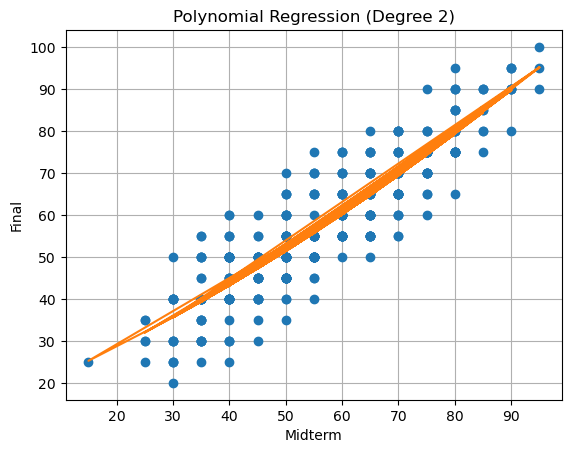

R2=0.7953162133015945
MSE=52.462193167140825


In [30]:
# try polynomial model midterm VS final
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2) 
X_poly = poly.fit_transform(X1.reshape(-1, 1))

model = LinearRegression()
model.fit(X_poly, X2)
y_pred = model.predict(X_poly)

plt.plot(X1, X2, 'o')
plt.plot(X1, y_pred, '-')
plt.title("Polynomial Regression (Degree 2)")
plt.xlabel("Midterm")
plt.ylabel("Final")
plt.grid(True)
plt.show()
print("R2=" + str(reg.score(X1.reshape(-1,1), X2)))
print("MSE=" + str(mean_squared_error(X2, y_pred)))
# the polynomial features to describe the midterm and final is pretty similar to the former case, but MSE relatively smaller.

R2=0.7947049272873864
MSE=53.32277315454673


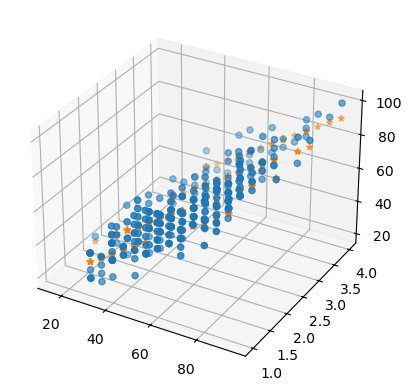

In [31]:
# study time and midterm vs final grade
# since study time's value range from 1 to 4, but midterm would be obviously bigger, therefore we scale the X arrays
from sklearn import linear_model as lm
from sklearn.metrics import mean_squared_error
X3 = df_cleaned['studytime'].values
X = np.concatenate((X3.reshape(-1,1), X1.reshape(-1,1)), axis=1)
scaler = pre.MinMaxScaler()
X_s = scaler.fit_transform(X)
reg = lm.SGDRegressor(max_iter=1000)
reg.fit(X_s, X2.ravel())
print("R2=" + str(reg.score(X_s, X2.ravel())))

yPred5 = reg.predict(X_s)
print("MSE=" + str(mean_squared_error(X2.ravel(), yPred5)))

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(X1,X3, X2, marker='o')
ax.scatter(X1,X3, yPred5, marker='*')

# The R2 is pretty good but compared with single factor mditerm it is smaller.
#this demostrates based on our degree 1 model:the study time is not that effective factor to make predictions but still a relatively good model.So how about considering feature engineering between studytime and midterm

In [32]:
#Feature Engineering  studytime and midterm  VS final X3 is studytime. Another Linear model: degree 2
# Here，we use the whole data for training, and R2 is based on these data. Yet, we haven't split the dataset into training and testing dataset. Just want to firstly get a quick overview.
# I am also interested in how the different training methods would have a influence on the fit of the model. So I adopt three methods here:
# RandomForest, LinearRegression and SGD regressor 
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

reg1 = RandomForestRegressor(n_estimators=100, random_state=0)
reg2 = LinearRegression()
reg3 =lm.SGDRegressor(max_iter=1000)
X1 = X1.ravel()
X3 = X3.ravel()
X2 = X2.ravel()
Xa = np.concatenate((
    X1.reshape(-1, 1),
    X3.reshape(-1, 1),
    (X1*X1).reshape(-1,1),
    (X3*X3).reshape(-1,1),
   (X1 * X3).reshape(-1, 1),
), axis=1)
Xa_scaled = scaler.fit_transform(Xa)

reg1.fit(Xa_scaled,X2)
reg2.fit(Xa_scaled,X2)
reg3.fit(Xa_scaled,X2)
yPred1 = reg1.predict(Xa_scaled)
yPred2 = reg2.predict(Xa_scaled)
yPred3 = reg3.predict(Xa_scaled)
print("Using RandomForestRegressor R2=" + str(reg1.score(Xa_scaled, X2)))
print("Random Forest MSE=" + str(mean_squared_error(X2, yPred1)))
print("Using Linear Regression R2=" + str(reg2.score(Xa_scaled, X2)))
print("Linear Regression MSE=" + str(mean_squared_error(X2, yPred2)))
print("Using SGDRegressor R2=" + str(reg3.score(Xa_scaled, X2)))
print("SGDRegressor MSE=" + str(mean_squared_error(X2, yPred3)))

# it seems the R2  RandomForest>Linear Regression> SGDRegressor MSE reverse order.  But overall, feature engineering slighly makes the model better. We choose this linear model instead. 

Using RandomForestRegressor R2=0.8182001353441657
Random Forest MSE=47.22019293731804
Using Linear Regression R2=0.7994916828468217
Linear Regression MSE=52.07947453335019
Using SGDRegressor R2=0.796986690534072
SGDRegressor MSE=52.73011429338779


In [33]:
# Here we measure how good the linear model(degree 1) performs by dividing the datasets. Note: This model does not use feature engineering.
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import numpy as np
train_X, test_X, train_y, test_y1 = train_test_split(X_s, X2, test_size=0.2, random_state=202)
scaler = pre.MinMaxScaler()
scaler.fit(train_X)
train_Xn = scaler.transform(train_X)
reg = LinearRegression()
reg.fit(train_Xn, train_y)
print("R2=" + str(reg.score(train_Xn, train_y)))


# Evaluate MSE on training dataset
train_yPred1 = reg.predict(train_Xn)
print("Train MSE: Mean Squared Error =" + str(mean_squared_error(train_y, train_yPred1)))
print("Train MAE: Mean Absolute Error =" + str(mean_absolute_error(train_y, train_yPred1)))
print("Train RMSE: Root mean squared error =" + str(np.sqrt(mean_squared_error(train_y, train_yPred1))))


# Evaluate MSE on test dataset
test_Xn = scaler.transform(test_X) # What happens here?
test_yPred1 = reg.predict(test_Xn)
print("Test MSE=" + str(mean_squared_error(test_y1, test_yPred1)))
print("Test MAE=" + str(mean_absolute_error(test_y1, test_yPred1)))
print("Test RMSE=" + str(np.sqrt(mean_squared_error(test_y1, test_yPred1))))
print("On test dataset R2=" + str(reg.score(test_Xn, test_y1)))
# it performs good. Now let us see how it is going with the linear model that uses feature engineering degree 2.

R2=0.7900292850794486
Train MSE: Mean Squared Error =52.93317131028512
Train MAE: Mean Absolute Error =5.907568796611338
Train RMSE: Root mean squared error =7.275518628268717
Test MSE=54.3038236568307
Test MAE=6.104392487982018
Test RMSE=7.369112813414564
On test dataset R2=0.8099952606391669


In [34]:
#Now is the othe linear model with feature engineering, now we create test data set, train data set, to see how our model performs on new data. Using  Linear regression method
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import numpy as np
train_X, test_X, train_y, test_y1 = train_test_split(Xa, X2, test_size=0.2, random_state=202)
scaler = pre.MinMaxScaler()
scaler.fit(train_X)
train_Xn = scaler.transform(train_X)
reg = LinearRegression()
reg.fit(train_Xn, train_y)
print("R2=" + str(reg.score(train_Xn, train_y)))


# Evaluate MSE on training dataset
train_yPred1 = reg.predict(train_Xn)
print("Train MSE: Mean Squared Error =" + str(mean_squared_error(train_y, train_yPred1)))
print("Train MAE: Mean Absolute Error =" + str(mean_absolute_error(train_y, train_yPred1)))
print("Train RMSE: Root mean squared error =" + str(np.sqrt(mean_squared_error(train_y, train_yPred1))))


# Evaluate MSE on test dataset
test_Xn = scaler.transform(test_X) # What happens here?
test_yPred1 = reg.predict(test_Xn)
print("Test MSE=" + str(mean_squared_error(test_y1, test_yPred1)))
print("Test MAE=" + str(mean_absolute_error(test_y1, test_yPred1)))
print("Test RMSE=" + str(np.sqrt(mean_squared_error(test_y1, test_yPred1))))
print("On test dataset R2=" + str(reg.score(test_Xn, test_y1)))


# We derive the results. R2, MSE, MAE, RMSE, on trained and test datasets. We can tell feature engineering is slightly better. Therefore we choose the feature engineering model(degree2)
# Also, we calculate R2 on test data, to demonstrate the Model generalization ability. Linear Regression one is best with feature engineering.

R2=0.792249165365079
Train MSE: Mean Squared Error =52.37354420470493
Train MAE: Mean Absolute Error =5.814011274016729
Train RMSE: Root mean squared error =7.236956833138148
Test MSE=51.821457359928374
Test MAE=5.868567717696682
Test RMSE=7.19871220149329
On test dataset R2=0.8186808619371837


In [13]:
# Now since we have chosen the linear model(the one with feature engineering), I want to see the three different training methods: linearregression,SGDregressor, Randomforest, how to choose the best training method.

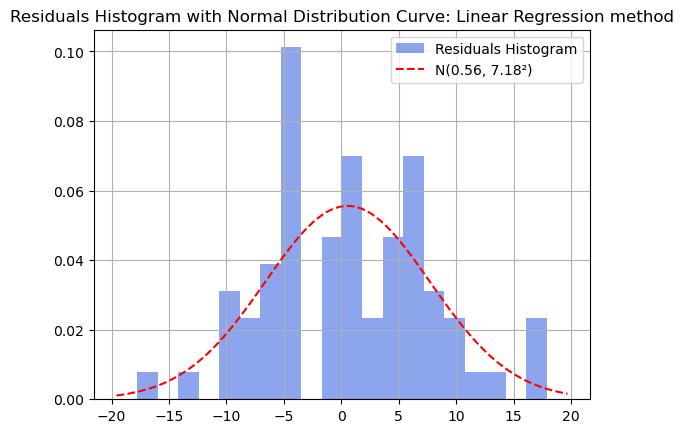

In [35]:
# This is for using method linear regression, we check its noise distribution
# I do this because a good model should make its error more like a bell shape
# Meanwhile , I have used stats lib to calculate the mean variance of noise and draw the normal distribution for better visualization.
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
residuals1 = test_y1 - test_yPred1
mu, std = np.mean(residuals1), np.std(residuals1)
plt.hist(residuals1, bins=20, density=True, alpha=0.6, color='royalblue', label='Residuals Histogram')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r--', label=f'N({mu:.2f}, {std:.2f}²)')

plt.title("Residuals Histogram with Normal Distribution Curve: Linear Regression method")
plt.legend()
plt.grid(True)
plt.show()

# we can see, using linear regression, its noise might not be ideal for a bell shape, but it looks like one.


In [36]:
#now create test data set, train data set, to see how our model performs on new data.Using random forest method. 
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(Xa, X2, test_size=0.2, random_state=202)
scaler = pre.MinMaxScaler()
scaler.fit(train_X)
train_Xn = scaler.transform(train_X)
reg = RandomForestRegressor(n_estimators=100, random_state=0)
reg.fit(train_Xn, train_y)
print("On training dataset R2=" + str(reg.score(train_Xn, train_y)))

# Evaluate MSE on training dataset
train_yPred = reg.predict(train_Xn)
print("Train MSE=" + str(mean_squared_error(train_y, train_yPred)))
print("Train MAE: Mean Absolute Error =" + str(mean_absolute_error(train_y, train_yPred)))
print("Train RMSE: Root mean squared error =" + str(np.sqrt(mean_squared_error(train_y, train_yPred))))





# Evaluate MSE on test dataset
test_Xn = scaler.transform(test_X) # What happens here?
test_yPred = reg.predict(test_Xn)
print("Test MSE=" + str(mean_squared_error(test_y, test_yPred)))
print("Test MAE=" + str(mean_absolute_error(test_y1, test_yPred)))
print("Test RMSE=" + str(np.sqrt(mean_squared_error(test_y1, test_yPred))))
print("On test dataset R2=" + str(reg.score(test_Xn, test_y)))


On training dataset R2=0.8204218368195266
Train MSE=45.27127356219685
Train MAE: Mean Absolute Error =5.392735337652286
Train RMSE: Root mean squared error =6.728393089155601
Test MSE=65.51381930757138
Test MAE=6.858655895897922
Test RMSE=8.094060742765116
On test dataset R2=0.7707723816884111


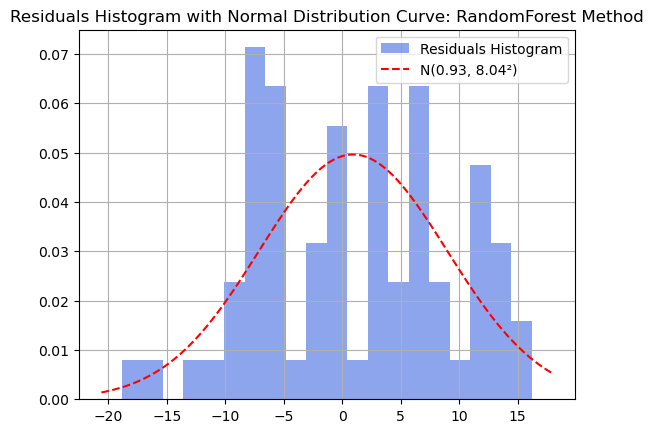

In [37]:
# This is for using method random forest
import matplotlib.pyplot as plt
import numpy as np

import scipy.stats as stats
residuals = test_y - test_yPred
mu, std = np.mean(residuals), np.std(residuals)
plt.hist(residuals, bins=20, density=True, alpha=0.6, color='royalblue', label='Residuals Histogram')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r--', label=f'N({mu:.2f}, {std:.2f}²)')

plt.title("Residuals Histogram with Normal Distribution Curve: RandomForest Method")
plt.legend()
plt.grid(True)
plt.show()

# you can tell, using randomforest method, the noise is not that good. 


In [38]:
#now create test data set, train data set, to see how our model performs on new data:Using SGD regressor
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(Xa, X2, test_size=0.2, random_state=202)
scaler = pre.MinMaxScaler()
scaler.fit(train_X)
train_Xn = scaler.transform(train_X)
reg = lm.SGDRegressor(penalty='elasticnet',alpha=0.005,l1_ratio=0.3,max_iter=10000,learning_rate='invscaling',eta0=0.01,early_stopping=True,validation_fraction=0.1,random_state=42)
reg.fit(train_X, train_y)
reg.fit(train_Xn, train_y)
print("On training dataset R2=" + str(reg.score(train_Xn, train_y)))

# Evaluate MSE on training dataset
train_yPred = reg.predict(train_Xn)
print("Train MSE=" + str(mean_squared_error(train_y, train_yPred)))
print("Train MAE: Mean Absolute Error =" + str(mean_absolute_error(train_y, train_yPred)))
print("Train RMSE: Root mean squared error =" + str(np.sqrt(mean_squared_error(train_y, train_yPred))))



# Evaluate MSE on test dataset
test_Xn = scaler.transform(test_X) # What happens here?
test_yPred = reg.predict(test_Xn)
print("Test MSE=" + str(mean_squared_error(test_y, test_yPred)))
print("Test MAE=" + str(mean_absolute_error(test_y1, test_yPred)))
print("Test RMSE=" + str(np.sqrt(mean_squared_error(test_y1, test_yPred))))
print("On test dataset R2=" + str(reg.score(test_Xn, test_y)))

On training dataset R2=0.762033834949619
Train MSE=59.99076483322727
Train MAE: Mean Absolute Error =6.194478822611919
Train RMSE: Root mean squared error =7.745370542022329
Test MSE=56.96163346300958
Test MAE=6.109262182750175
Test RMSE=7.547293121577403
On test dataset R2=0.800695796522515


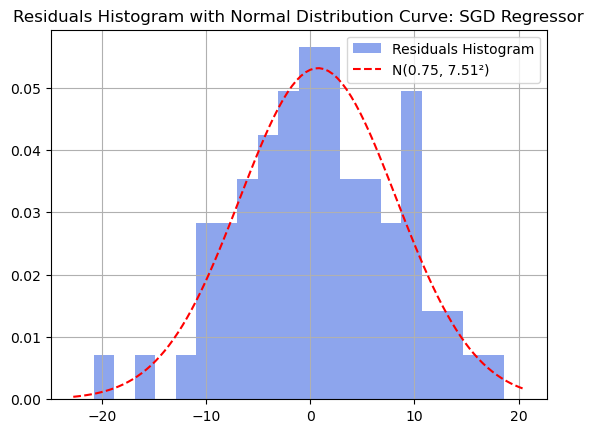

In [39]:
#first we draw the distribution of the error whether it is close to gaussian distribution if it's gaussian white noise. This is for method using sgd regressor.

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
residuals = test_y - test_yPred
mu, std = np.mean(residuals), np.std(residuals)
plt.hist(residuals, bins=20, density=True, alpha=0.6, color='royalblue', label='Residuals Histogram')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r--', label=f'N({mu:.2f}, {std:.2f}²)')

plt.title("Residuals Histogram with Normal Distribution Curve: SGD Regressor")
plt.legend()
plt.grid(True)
plt.show()

# The method of sgd regressor has beautiful bell curve. 


In [19]:
#residuals distribution histogram it looks like a gaussian distribution
# discussion, we have seen the error of sgd regressor most like the normal distribution.
# So far, let's make a conclusion. We use feature engineering to make the linear model which makes model perform better.
# Linear regression's R2 on training data is ranked second but on new data R2 is the biggest among the three methods.
# Random Forest's R2 on training data is the best but on new data, R2, it's model generalization ability ranked poorly.
# SGD regressor is sort of ranked middle, but the noise seems the best as the normal distribution.

# Therefore I would choose sgd regressor as the method to train the model. since I only use two explanatory variables that I deem important.


Pearson Correlation Coefficient: 0.909


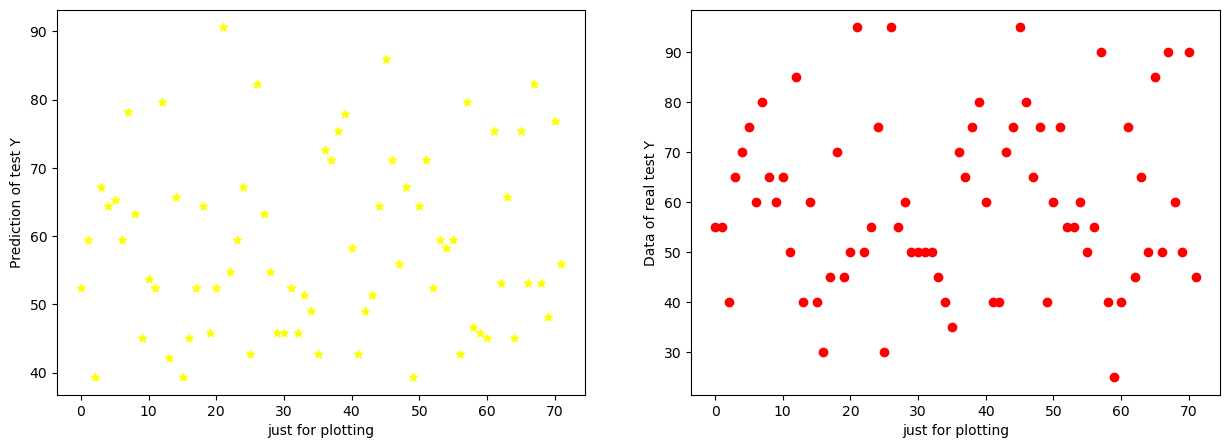

In [40]:
# This is the scatter point of testY and test YPred, you can see how similar they are, and how good the model predicts(using method of sgd regressor)
xIndex = np.arange(test_yPred.size)
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(15,5))
ax1.scatter(xIndex,test_yPred,color = 'yellow',marker = '*')
ax1.set_xlabel("just for plotting")
ax2.set_xlabel("just for plotting")
ax1.set_ylabel("Prediction of test Y")
ax2.set_ylabel("Data of real test Y")
ax2.scatter(xIndex, test_y, color = 'red', marker = 'o')
from scipy.stats import pearsonr
corr, _ = pearsonr(test_yPred, test_y)
print(f"Pearson Correlation Coefficient: {corr:.3f}") # Here I use Pearson coefficent to see the linear relationship between my real test Y and test YPred(generated by model)


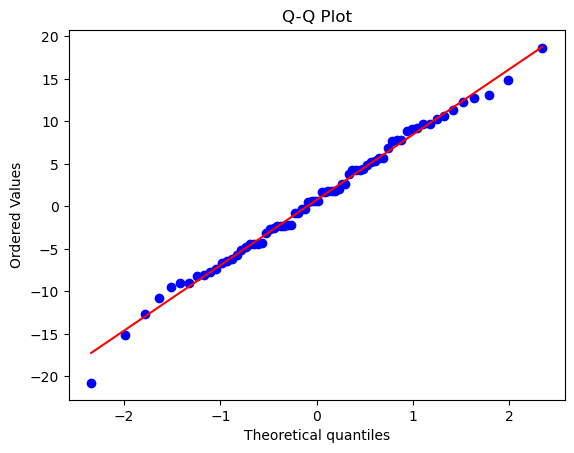

In [41]:
#another way to evaluate the model, qqplot, which uses the mean and standard divation of the sample, and make a gaussian distribution and compare with the error with respect to their percentage(small to big)
# This is for model using linear regression to train
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

# You can see how good it fits the line. Our model should be successful. 


In [22]:
print("X1 shape:", X1.shape)
print("X3 shape:", X3.shape)
print("X1*X3 shape:", (X1 * X3).shape)


X1 shape: (357,)
X3 shape: (357,)
X1*X3 shape: (357,)
